# Task 2: News Category Classification

**Description:**

- Dataset (Recommended): AG News (Kaggle)
- Classify news articles into categories such as sports, business, politics, technology, etc.
- Perform standard text preprocessing (tokenization, stopword removal, lemmatization)
- Vectorize the text using TF-IDF or word embeddings
- Train a multiclass classifier (e.g., Logistic Regression, Random Forest, or SVM)

**Tools & Libraries:**

| Pandas | Scikit-learn    | Optionally: XGBoost or LightGBM    |
|---|---|---|

**Covered Topics**

Multiclass classification | Text preprocessing | Feature engineering with text

**Bonus:**

Visualize the most frequent words per category using bar plots or word clouds  
Try training the model using a neural network (e.g., simple feedforward NN with Keras)

In [2]:
import pandas as pd

df_train = pd.read_csv("/kaggle/input/ag-news-classification-dataset/train.csv")
print(df_train.shape, "\n**************************\n")
print(df_train.info(), "\n**************************\n")
print(df_train.tail(3), "\n**************************\n")
print(df_train.columns, "\n**************************\n")

(120000, 3) 
**************************

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Class Index  120000 non-null  int64 
 1   Title        120000 non-null  object
 2   Description  120000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB
None 
**************************

        Class Index                            Title  \
119997            2  Saban not going to Dolphins yet   
119998            2                Today's NFL games   
119999            2     Nets get Carter from Raptors   

                                              Description  
119997  The Miami Dolphins will put their courtship of...  
119998  PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: ...  
119999  INDIANAPOLIS -- All-Star Vince Carter was trad...   
**************************

Index(['Class Index', 'Title', 'Description'], dtype='object'

In [3]:
df_test = pd.read_csv("/kaggle/input/ag-news-classification-dataset/test.csv")
print(df_test.shape, "\n**************************\n")
print(df_test.info(), "\n**************************\n")
print(df_test.tail(3), "\n**************************\n")
print(df_test.columns, "\n**************************\n")

(7600, 3) 
**************************

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7600 entries, 0 to 7599
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Class Index  7600 non-null   int64 
 1   Title        7600 non-null   object
 2   Description  7600 non-null   object
dtypes: int64(1), object(2)
memory usage: 178.3+ KB
None 
**************************

      Class Index                                              Title  \
7597            2                             Martinez leaves bitter   
7598            3  5 of arthritis patients in Singapore take Bext...   
7599            3                             EBay gets into rentals   

                                            Description  
7597  Like Roger Clemens did almost exactly eight ye...  
7598  SINGAPORE : Doctors in the United States have ...  
7599  EBay plans to buy the apartment and home renta...   
**************************

Index(['Class 

# **A) Cleaning**

**1. Redundant Columns**
- Merge/Rename
- Drop

**2. Duplicates**
* Check: `df_train.duplicated().sum()`
* Drop: `df_train.drop_duplicates(inplace=True)`

**3. Outliers**
* Check values: `df_train['sentiment'].value_counts()`
* Check data type: `print(all(isinstance(item, str) for item in df_train['review']))`

**4. Missing values**
* Check: `df_train.isna().sum()`
* Drop: `df_train.dropna()`
* Clean empty strings: `np.sum(df_train['Description'].values == r"\s*")`
* Reset index: `df_train.reset_index()`

In [4]:
df_train["Text"] = df_train["Title"] + " " + df_train["Description"]
df_train = df_train.drop(['Title', 'Description'], axis=1)

df_train.tail(3)

,Class Index,Text
119997,2,Saban not going to Dolphins yet The Miami Dolp...
119998,2,Today's NFL games PITTSBURGH at NY GIANTS Time...
119999,2,Nets get Carter from Raptors INDIANAPOLIS -- A...


In [5]:
df_test["Text"] = df_test["Title"] + " " + df_test["Description"]
df_test = df_test.drop(['Title', 'Description'], axis=1)

df_test.tail(3)

,Class Index,Text
7597,2,Martinez leaves bitter Like Roger Clemens did ...
7598,3,5 of arthritis patients in Singapore take Bext...
7599,3,EBay gets into rentals EBay plans to buy the a...


In [6]:
df_train.duplicated().sum()

0

In [7]:
df_test.duplicated().sum()

0

<Axes: xlabel='Class Index'>

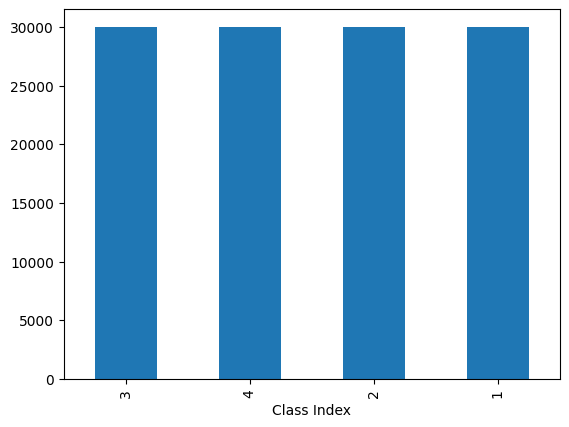

In [8]:
df_train["Class Index"].value_counts().plot(kind="bar")

In [9]:
df_test["Class Index"].value_counts()

Class Index
3    1900
4    1900
2    1900
1    1900
Name: count, dtype: int64

In [10]:
print(all(isinstance(item, str) for item in df_train['Text']))
print(all(isinstance(item, int) for item in df_train['Class Index']))

True
True


In [11]:
print(all(isinstance(item, str) for item in df_test['Text']))
print(all(isinstance(item, int) for item in df_test['Class Index']))

True
True


In [12]:
import numpy as np

print(np.sum(df_train['Text'].values == r"\s*"))

0


In [13]:
print(np.sum(df_test['Text'].values == r"\s*"))

0


# **B) Preprocessing**

### 1. **Numerical Features**

- **Scaling**: `StandardScaler` (Z-score), `MinMaxScaler` (diff ranges), `RobustScaler` (outliers)
- **Normalization**
- **Handling missing values** (mean/median imputation)

*If you use tree-based (Thresh) models (Random Forest, XGBoost, LightGBM) → No need to scale, No need to ONE-HOT encode)*

*If you use linear models, neural nets, SVM, k-NN → scaling/norm is important, need ONE-HOT encode*

---

### 2. **Categorical Features**
#### low-cardinality categories
- **One-Hot Encoding** (`pd.get_dummies`, `OneHotEncoder`)
- **Label Encoding** (Ordinal values ~ have order)

#### high-cardinality categories
- **Target Encoding** (average of group)
- **Frequency encoding** (#Occurance)
- **Grouping rare categories** "Other"

---

### 3. **Text Features**
- **lowering**
- **Abbreviations** (shouldn't -> should not)
- **RegEx** (a-z only, spaces)
- **Tokenization**
- **Stopwords** (except no, not, nor)
- **Embeddings / Vectorization**
 
- **Frequency based** (TF-IDF, Bag-of-Words, Count-Vectorizer)
- **Pre-trained Prediction based** (Word2Vec, GloVe, FastText)
- **Transformers Contextual based** (BERT, etc.)

---

### 4. **Date/Time Features**

- **Extract components** (day, month, weekday, hour, season)
- **Time differences**
- **Cyclical encoding** for periodic features (sin/cos transform)


In [14]:
"""
1 represents World, 
2 represents Sports, 
3 represents Business, 
4 represents Sci/Tech. 
"""

'\n1 represents World, \n2 represents Sports, \n3 represents Business, \n4 represents Sci/Tech. \n'

In [15]:
df_train["Class Index"] = df_train["Class Index"].replace({1: 0, 2: 1, 3: 2, 4: 3})
print(df_train["Class Index"].value_counts())
df_train.tail(3)

Class Index
2    30000
3    30000
1    30000
0    30000
Name: count, dtype: int64


,Class Index,Text
119997,1,Saban not going to Dolphins yet The Miami Dolp...
119998,1,Today's NFL games PITTSBURGH at NY GIANTS Time...
119999,1,Nets get Carter from Raptors INDIANAPOLIS -- A...


In [16]:
df_test["Class Index"] = df_test["Class Index"].replace({1: 0, 2: 1, 3: 2, 4: 3})
print(df_test["Class Index"].value_counts())
df_test.tail(3)

Class Index
2    1900
3    1900
1    1900
0    1900
Name: count, dtype: int64


,Class Index,Text
7597,1,Martinez leaves bitter Like Roger Clemens did ...
7598,2,5 of arthritis patients in Singapore take Bext...
7599,2,EBay gets into rentals EBay plans to buy the a...


In [17]:
df_train["Class Label"] = df_train["Class Index"].replace({0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"})
print(df_train["Class Label"].value_counts())
df_train.tail(3)

Class Label
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64


,Class Index,Text,Class Label
119997,1,Saban not going to Dolphins yet The Miami Dolp...,Sports
119998,1,Today's NFL games PITTSBURGH at NY GIANTS Time...,Sports
119999,1,Nets get Carter from Raptors INDIANAPOLIS -- A...,Sports


In [18]:
df_test["Class Label"] = df_test["Class Index"].replace({0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"})
print(df_test["Class Label"].value_counts())
df_test.tail(3)

Class Label
Business    1900
Sci/Tech    1900
Sports      1900
World       1900
Name: count, dtype: int64


,Class Index,Text,Class Label
7597,1,Martinez leaves bitter Like Roger Clemens did ...,Sports
7598,2,5 of arthritis patients in Singapore take Bext...,Business
7599,2,EBay gets into rentals EBay plans to buy the a...,Business


In [19]:
df_train["Class Index"].unique()

array([2, 3, 1, 0])

In [20]:
df_test["Class Index"].unique()

array([2, 3, 1, 0])

In [21]:
df_train_OHE = pd.get_dummies(df_train, columns=["Class Index"], prefix="cls", prefix_sep="_", dtype=int)
df_train_OHE["Class Index"] = df_train["Class Index"]
df_train_OHE.tail(5)

,Text,Class Label,cls_0,cls_1,cls_2,cls_3,Class Index
119995,Pakistan's Musharraf Says Won't Quit as Army C...,World,1,0,0,0,0
119996,Renteria signing a top-shelf deal Red Sox gene...,Sports,0,1,0,0,1
119997,Saban not going to Dolphins yet The Miami Dolp...,Sports,0,1,0,0,1
119998,Today's NFL games PITTSBURGH at NY GIANTS Time...,Sports,0,1,0,0,1
119999,Nets get Carter from Raptors INDIANAPOLIS -- A...,Sports,0,1,0,0,1


In [22]:
df_test_OHE = pd.get_dummies(df_test, columns=["Class Index"], prefix="cls", prefix_sep="_", dtype=int)
df_test_OHE["Class Index"] = df_test["Class Index"]
df_test_OHE.tail(5)

,Text,Class Label,cls_0,cls_1,cls_2,cls_3,Class Index
7595,Around the world Ukrainian presidential candid...,World,1,0,0,0,0
7596,Void is filled with Clement With the supply of...,Sports,0,1,0,0,1
7597,Martinez leaves bitter Like Roger Clemens did ...,Sports,0,1,0,0,1
7598,5 of arthritis patients in Singapore take Bext...,Business,0,0,1,0,2
7599,EBay gets into rentals EBay plans to buy the a...,Business,0,0,1,0,2


# **C) Embeddings / Vectorization**
 
### 1. **Frequency based** 

- **TF-IDF**
- **Bag-of-Words**
- **Count-Vectorizer**

### 2. **Pre-trained Prediction based** 

- **Word2Vec**
- **GloVe**
- **FastText**

### 3. **Transformers Contextual based**

- **BERT**
- **etc.**

## TFIDF

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(ngram_range=(1, 3), max_features=10000)
X_train_tfidf = tfidf.fit_transform(df_train_OHE["Text"])
y_train_tfidf = (df_train_OHE['Class Index']).values
print(X_train_tfidf.shape)

(120000, 10000)


In [24]:
X_test_tfidf = tfidf.transform(df_test_OHE["Text"])
y_test_tfidf = (df_test_OHE['Class Index']).values

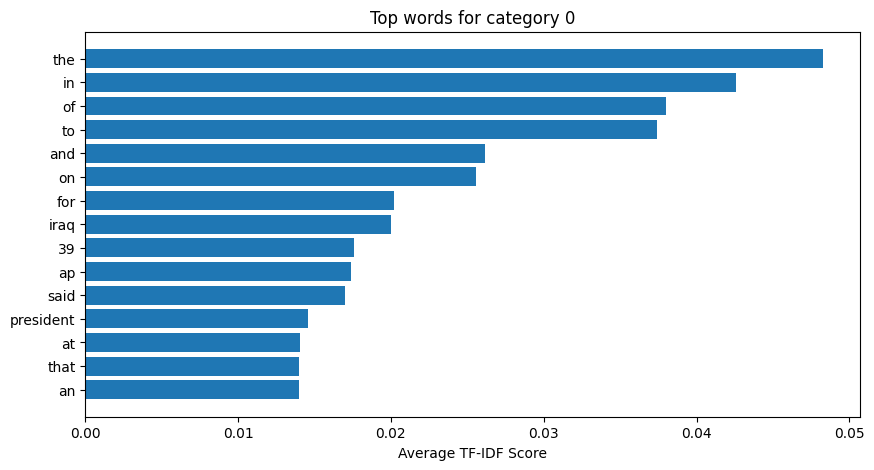

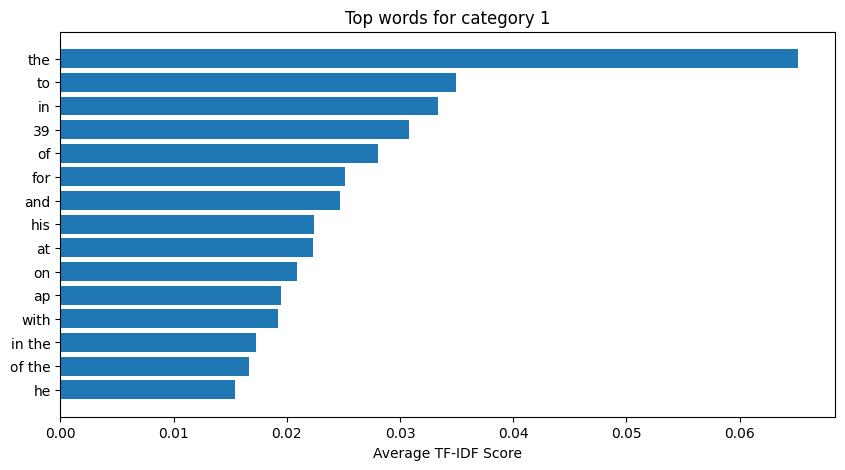

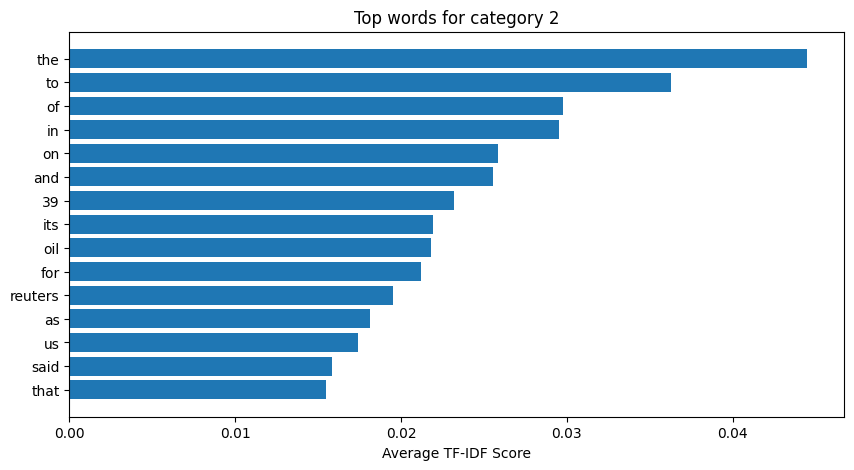

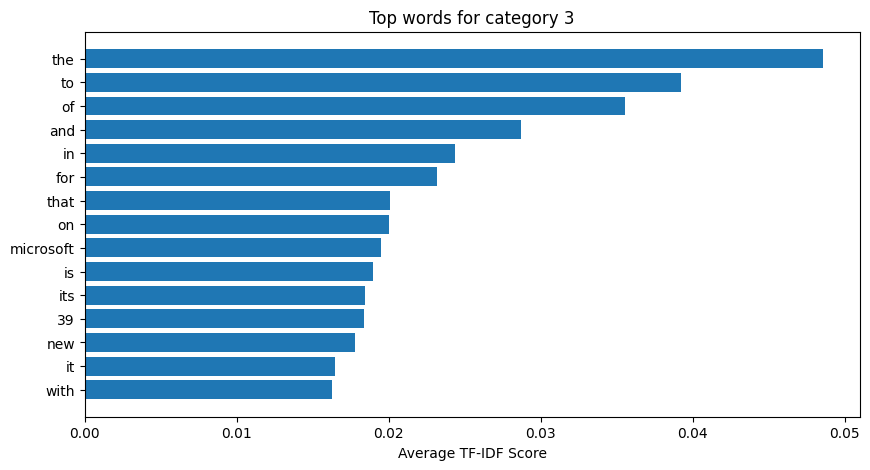

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Vectorize
tfidf = TfidfVectorizer(ngram_range=(1, 3), max_features=10000)
X_tfidf = tfidf.fit_transform(df_train_OHE["Text"])
y = df_train_OHE['Class Index']

feature_names = np.array(tfidf.get_feature_names_out())

# Loop over categories
for category in sorted(y.unique()):
    idx = np.where(y == category)[0]
    category_tfidf = X_tfidf[idx].mean(axis=0).A1  # average tf-idf scores
    
    top_indices = category_tfidf.argsort()[::-1][:15]  # top 15
    top_features = feature_names[top_indices]
    top_scores = category_tfidf[top_indices]
    
    plt.figure(figsize=(10,5))
    plt.barh(top_features[::-1], top_scores[::-1])
    plt.title(f"Top words for category {category}")
    plt.xlabel("Average TF-IDF Score")
    plt.show()


In [26]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression

logregr = LogisticRegression(random_state=42, max_iter=1000)
logregr.fit(X_train_tfidf, y_train_tfidf)

LogisticRegression(max_iter=1000, random_state=42)

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.91      1900
           1       0.95      0.97      0.96      1900
           2       0.88      0.87      0.88      1900
           3       0.88      0.89      0.89      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



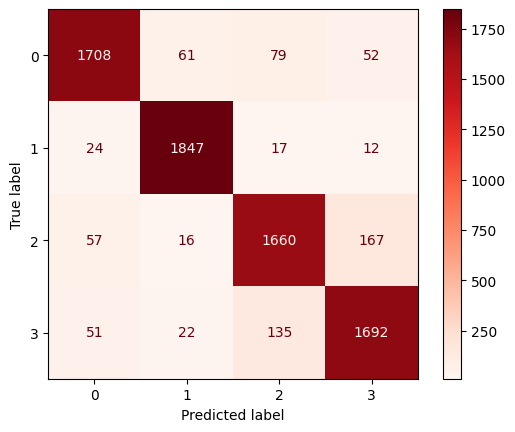

In [41]:
y_pred_tfidf = logregr.predict(X_test_tfidf)
cm_tfidf = confusion_matrix(y_test_tfidf, y_pred_tfidf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tfidf)
disp.plot(cmap="Reds", values_format="d")
cr_logst = classification_report(y_test_tfidf, y_pred_tfidf)
print(f"Classification report:\n{cr}")

In [61]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

for n in [100]:
    model = XGBClassifier(
        n_estimators=300,
        max_depth=20,
        random_state=42,
        tree_method='hist',  # Use GPU for histogram-based algorithm
        device='cuda'           # Use CUDA device (GPU)
    )
    
    model.fit(X_train_tfidf, y_train_tfidf)
    
    acc = model.score(X_test_tfidf, y_test_tfidf)
    print(f"n_estimators={n}, Test Accuracy={acc:.4f}")

n_estimators=100, Test Accuracy=0.2492


Test Accuracy: 0.24921052631578947
              precision    recall  f1-score   support

           0       0.11      0.00      0.00      1900
           1       0.25      0.95      0.40      1900
           2       0.31      0.03      0.05      1900
           3       0.17      0.02      0.04      1900

    accuracy                           0.25      7600
   macro avg       0.21      0.25      0.12      7600
weighted avg       0.21      0.25      0.12      7600



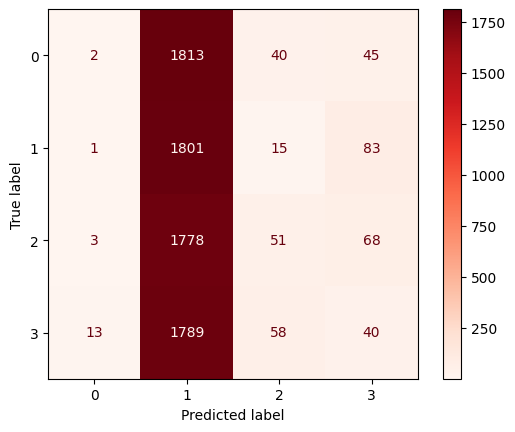

In [62]:
y_pred_tfidf = model.predict(X_test_tfidf)
print("Test Accuracy:", accuracy_score(y_test_tfidf, y_pred_tfidf))
print(classification_report(y_test_tfidf, y_pred_tfidf))

cm_tfidf = confusion_matrix(y_test_tfidf, y_pred_tfidf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tfidf)
disp.plot(cmap="Reds", values_format="d")

In [31]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

X_train, X_val, y_train, y_val = train_test_split(
    X_train_tfidf, y_train_tfidf, test_size=0.2, random_state=42, stratify=y_train_tfidf
)

model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(4, activation='softmax') 
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │     1,280,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,288,644 (4.92 MB)

 Trainable params: 1,288,644 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=60000)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 5s/step - accuracy: 0.3058 - loss: 1.3844 - val_accuracy: 0.6986 - val_loss: 1.3687
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 5s/step - accuracy: 0.6653 - loss: 1.3661 - val_accuracy: 0.8183 - val_loss: 1.3398
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 5s/step - accuracy: 0.7986 - loss: 1.3368 - val_accuracy: 0.8450 - val_loss: 1.2995
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 5s/step - accuracy: 0.8343 - loss: 1.2965 - val_accuracy: 0.8554 - val_loss: 1.2492
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 6s/step - accuracy: 0.8482 - loss: 1.2471 - val_accuracy: 0.8604 - val_loss: 1.1911
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 5s/step - accuracy: 0.8539 - loss: 1.1901 - val_accuracy: 0.8633 - val_loss: 1.1268
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 5s/step - accuracy: 0.8571 - loss: 1.1276 - val_accuracy: 0.8655 - val_loss: 1.0578
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 5s/step - accuracy: 0.8603 - loss: 1.0600 - val_accuracy: 0.8681 - val_loss: 0.9852
Epoch 9/

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9004 - loss: 0.2952
Model Accuracy on the test set: 0.9041


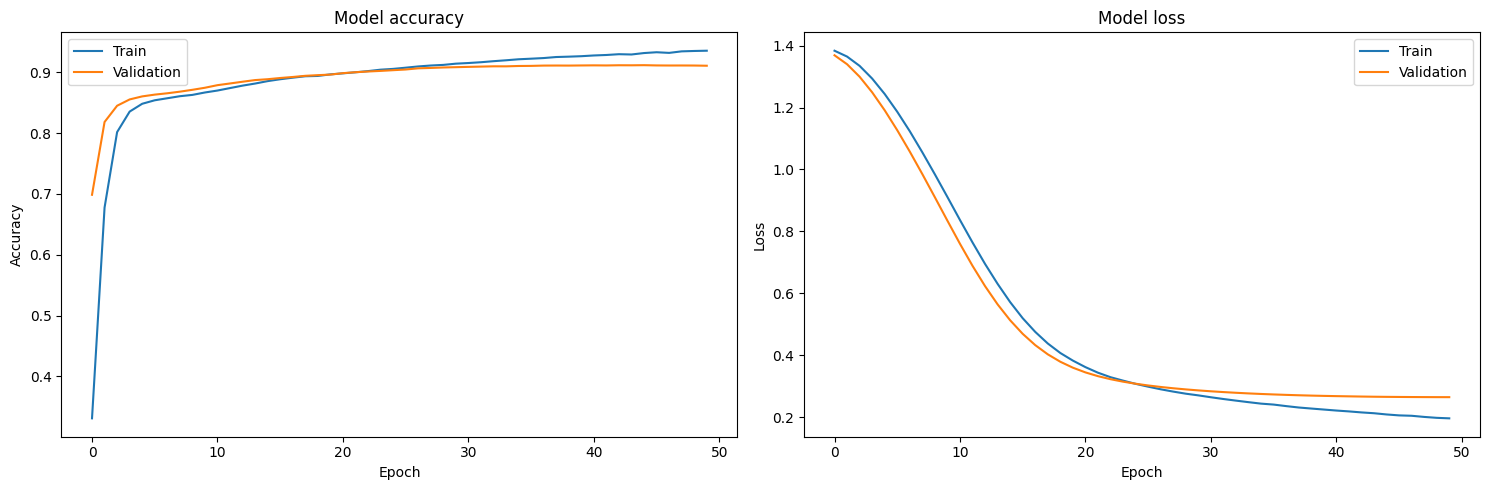

In [34]:
import matplotlib.pyplot as plt
loss, accuracy = model.evaluate(X_test_tfidf, y_test_tfidf, verbose=1)
print(f"Model Accuracy on the test set: {accuracy:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot training & validation accuracy values
ax1.plot(history.history['accuracy'])
ax1.plot(history.history['val_accuracy'])
ax1.set_title('Model accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
ax2.plot(history.history['loss'])
ax2.plot(history.history['val_loss'])
ax2.set_title('Model loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend(['Train', 'Validation'], loc='upper right')

plt.tight_layout()
plt.show()

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Classification report:
              precision    recall  f1-score   support

           0       0.92      0.89      0.91      1900
           1       0.95      0.97      0.96      1900
           2       0.87      0.86      0.87      1900
           3       0.87      0.89      0.88      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



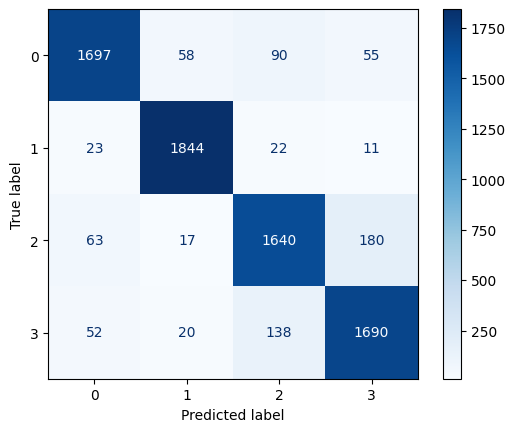

In [36]:
y_pred_probs = model.predict(X_test_tfidf)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion matrix
cm_tfidf = confusion_matrix(y_test_tfidf, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tfidf)
disp.plot(cmap="Blues", values_format="d")

# Classification report
cr = classification_report(y_test_tfidf, y_pred)
print(f"Classification report:\n{cr}")

## W2V

In [52]:
import re
import html
import unicodedata as unic
from bs4 import BeautifulSoup

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("punkt")      # tokenizer
nltk.download('punkt_tab')
nltk.download('stopwords')  # stopwords
nltk.download('wordnet')    # lemmatizer
nltk.download("omw-1.4")

# replace only:
#  's -> is, us, has
#  'm -> am
#  're -> are
#  've -> have
#  't -> not
#  'll -> will
#  'd -> would, had
abbreviations = {
    "aren't": "are not",
    "can't": "cannot",
    "couldn't": "could not",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "he would",
    "he'll": "he will",
    "he's": "he is",
    "i'd": "i would",
    "i'll": "i will",
    "i'm": "i am",
    "i've": "i have",
    "isn't": "is not",
    "it'd": "it would",
    "it'll": "it will",
    "it's": "it is",
    "let's": "let us",
    "mightn't": "might not",
    "mustn't": "must not",
    "shan't": "shall not",
    "she'd": "she would",
    "she'll": "she will",
    "she's": "she is",
    "shouldn't": "should not",
    "that's": "that is",
    "there's": "there is",
    "they'd": "they would",
    "they'll": "they will",
    "they're": "they are",
    "they've": "they have",
    "wasn't": "was not",
    "we'd": "we would",
    "we'll": "we will",
    "we're": "we are",
    "we've": "we have",
    "weren't": "were not",
    "what's": "what is",
    "where's": "where is",
    "who'd": "who would",
    "who'll": "who will",
    "who's": "who is",
    "won't": "will not",
    "wouldn't": "would not",
    "you'd": "you would",
    "you'll": "you will",
    "you're": "you are",
    "you've": "you have"
}

def replace_abbreviations(text):
    for abbr, full in abbreviations.items():
        pattern = r"\b" + re.escape(abbr) + r"\b"
        text = re.sub(pattern, full, text, flags=re.IGNORECASE)
    return text


def tfidf_preprocessing(df_train, col):
    # decode HTML entities and tags
    df_train[col] = df_train[col].apply(lambda x: html.unescape(x))
    df_train[col] = df_train[col].apply(lambda x: BeautifulSoup(x, "html.parser").get_text())
    
    # lowercase + remove accents
    df_train[col] = df_train[col].str.lower()
    df_train[col] = df_train[col].apply(lambda x: unic.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8", "ignore"))

    # replace abbreviations
    df_train[col] = df_train[col].apply(replace_abbreviations)

    # clean special chars & collapse spaces
    df_train[col] = (df_train[col]
        .str.replace(r"[^a-z\s]", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    return df_train[col]


def w2v_preprocessing(df_train, col):
    
    # tokenize
    df_train[col] = df_train[col].apply(word_tokenize)

    # remove stopwords (keep no, not, nor)
    stop_words = set(stopwords.words("english"))
    df_train[col] = df_train[col].apply(
        lambda tokens: [word for word in tokens if (word not in stop_words) or (word in {"no", "not", "nor"})]
    )

    # lemmatize
    lemmatizer = WordNetLemmatizer()
    df_train[col] = df_train[col].apply(lambda tokens: [lemmatizer.lemmatize(word) for word in tokens])
  
    return df_train[col]

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


In [53]:
df_train_tk = df_train_OHE.copy()
columns_to_process = ['Text']

for col in columns_to_process:
    df_train_tk[col] = tfidf_preprocessing(df_train_tk, col)
    df_train_tk[col] = w2v_preprocessing(df_train_tk, col)

df_train_tk.tail(3)

,Text,Class Label,cls_0,cls_1,cls_2,cls_3,Class Index
119997,"[saban, not, going, dolphin, yet, miami, dolph...",Sports,0,1,0,0,1
119998,"[today, nfl, game, pittsburgh, ny, giant, time...",Sports,0,1,0,0,1
119999,"[net, get, carter, raptor, indianapolis, star,...",Sports,0,1,0,0,1


In [54]:
df_test_tk = df_test_OHE.copy()
columns_to_process = ['Text']

for col in columns_to_process:
    df_test_tk[col] = tfidf_preprocessing(df_test_tk, col)
    df_test_tk[col] = w2v_preprocessing(df_test_tk, col)

df_test_tk.tail(5)

,Text,Class Label,cls_0,cls_1,cls_2,cls_3,Class Index
7595,"[around, world, ukrainian, presidential, candi...",World,1,0,0,0,0
7596,"[void, filled, clement, supply, attractive, pi...",Sports,0,1,0,0,1
7597,"[martinez, leaf, bitter, like, roger, clemens,...",Sports,0,1,0,0,1
7598,"[arthritis, patient, singapore, take, bextra, ...",Business,0,0,1,0,2
7599,"[ebay, get, rental, ebay, plan, buy, apartment...",Business,0,0,1,0,2


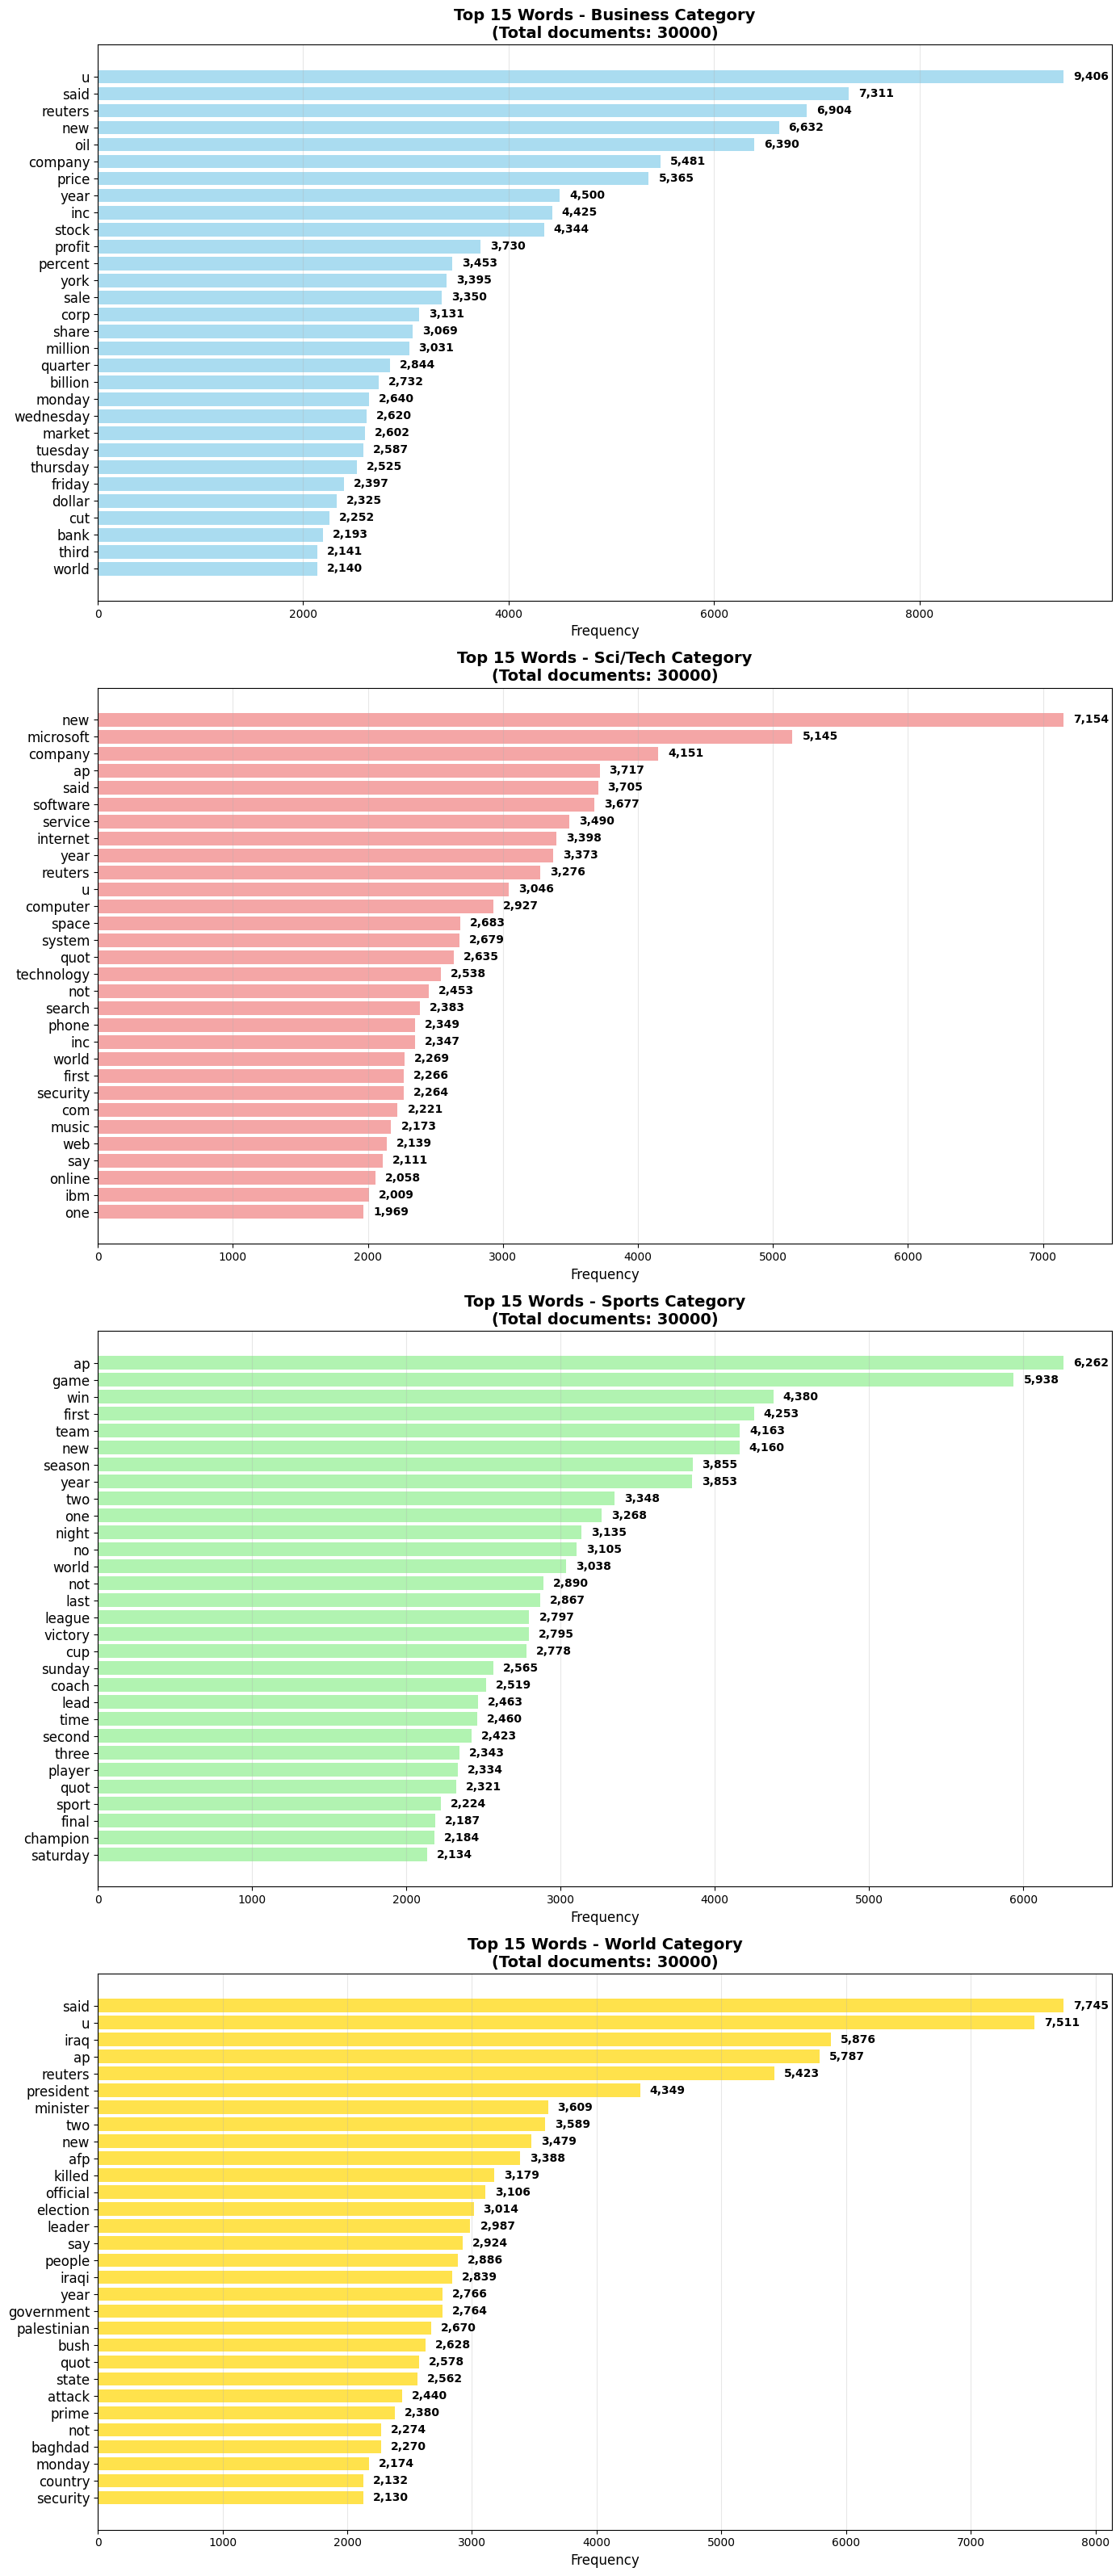

   Category  Documents  Total Tokens  Unique Tokens  Vocab Diversity
0  Business      30000        772634          23449            0.030
1  Sci/Tech      30000        753355          27847            0.037
2    Sports      30000        731869          26956            0.037
3     World      30000        788979          25456            0.032


In [38]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

categories = df_train_tk['Class Label'].unique()

# Create subplots - one for each category
fig, axes = plt.subplots(len(categories), 1, figsize=(14, 8 * len(categories)))
plt.subplots_adjust(hspace=0.4)

colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold']

for i, category in enumerate(categories):
    category_data = df_train_tk[df_train_tk['Class Label'] == category]
    
    # Combine all tokenized text for this category
    all_tokens = []
    for tokens_list in category_data['Text']:
        all_tokens.extend(tokens_list)
    
    # Count token frequencies
    token_counts = Counter(all_tokens)
    top_tokens = token_counts.most_common(30)
    
    # Separate tokens and counts for plotting
    tokens_list = [token for token, count in top_tokens]
    counts_list = [count for token, count in top_tokens]
    
    # Create horizontal bar plot (better for text readability)
    y_pos = np.arange(len(tokens_list))
    axes[i].barh(y_pos, counts_list, align='center', color=colors[i % len(colors)], alpha=0.7)
    axes[i].set_yticks(y_pos)
    axes[i].set_yticklabels(tokens_list, fontsize=12)
    axes[i].invert_yaxis()  # labels read top-to-bottom
    axes[i].set_xlabel('Frequency', fontsize=12)
    axes[i].set_title(f'Top 15 Words - {category} Category\n(Total documents: {len(category_data)})', 
                     fontsize=14, fontweight='bold')
    
    # Add grid for better readability
    axes[i].grid(axis='x', alpha=0.3)
    
    # Add value labels on bars
    for j, count in enumerate(counts_list):
        axes[i].text(count + max(counts_list)*0.01, j, f'{count:,}', 
                    va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


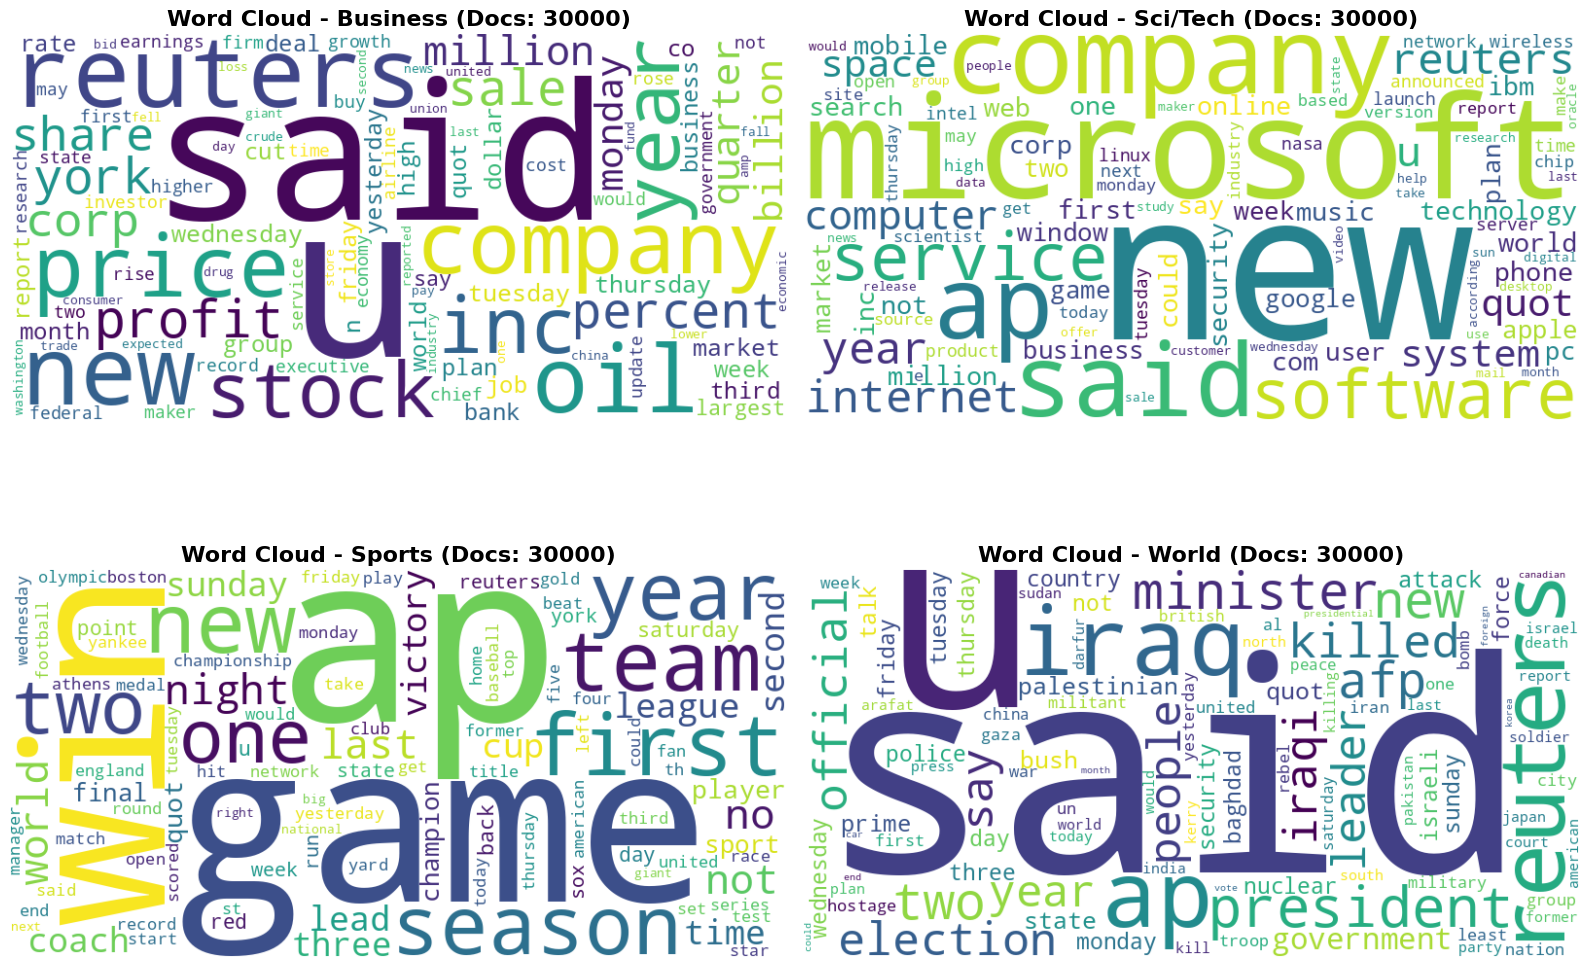

In [36]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

# Unique categories
categories = df_train_tk['Class Label'].unique()

# Define colors for each category
colors = ['Blues', 'Reds', 'Greens', 'Oranges']

# Create a subplot grid (2 columns for neat layout)
rows = (len(categories) + 1) // 2
fig, axes = plt.subplots(rows, 2, figsize=(16, 6 * rows))
axes = axes.flatten()

for i, category in enumerate(categories):
    # Filter category data
    category_data = df_train_tk[df_train_tk['Class Label'] == category]

    # Combine tokens
    all_tokens = []
    for tokens_list in category_data['Text']:
        all_tokens.extend(tokens_list)

    # Count token frequencies
    token_counts = Counter(all_tokens)

    # Generate word cloud
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        max_words=100
    ).generate_from_frequencies(token_counts)

    # Plot
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f"Word Cloud - {category} (Docs: {len(category_data)})",
                      fontsize=16, fontweight='bold')
    axes[i].axis('off')

# Hide empty subplots (if odd number of categories)
for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


### from gensim.models import Word2Vec

w2v_model = Word2Vec(sentences=df_train_tk["Text"], vector_size=100, window=5, min_count=1, workers=4, sg=0) # CBOW
w2v_model.wv.index_to_key[:10]  # most frequent words

In [56]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(sentences=df_test_tk["Text"], vector_size=100, window=5, min_count=1, workers=4, sg=0) # CBOW
w2v_model.wv.index_to_key[:10]  # most frequent words

['u',
 'new',
 'said',
 'reuters',
 'ap',
 'year',
 'two',
 'company',
 'first',
 'quot']

That function is crucial if you want to use Word2Vec embeddings for classification, because:

Word2Vec gives you embeddings per word, but classifiers like Logistic Regression, XGBoost, SVM, Random Forest expect fixed-length vectors per document.

The function takes a list of tokens (a document) and averages their embeddings → giving you one vector per document. That’s your feature input.

👉 If you skip it, you won’t have a consistent X matrix (every sample must have same dimensionality). Models like Logistic Regression or XGBoost can’t handle variable-length sequences directly.

In [57]:
# Text → Tokens → Vectors (tok num) → Aggregation (aveDoc num) → Classifier input

def document_vector(doc, w2v_model):
    # Remove out-of-vocabulary words
    doc = [word for word in doc if word in w2v_model.wv]
    if len(doc) == 0:
        return np.zeros(w2v_model.vector_size)
    return np.mean(w2v_model.wv[doc], axis=0)


- For **traditional classifiers** (LogReg, RF, SVM, XGBoost), you need fixed-length vectors.  
- **Mean pooling** (or TF-IDF weighted average of embeddings) is the standard way.  
- To better preserve word order/semantics → use **sequence models** (RNN, LSTM, Transformers).  

✅ Practical advice:  
- Start with **mean pooled embeddings** as baseline.  
- Try **TF-IDF weighted embeddings** for improvement.  
- For full sentence semantics, use **BERT** or similar pretrained models for document embeddings.  


In [63]:
from sklearn.model_selection import train_test_split

X_train_w2v = np.array([document_vector(tokens, w2v_model) for tokens in df_train_tk["Text"]])
y_train_w2v = df_train_tk["Class Index"].values

# X_train, X_val, y_train, y_val = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )


In [64]:
X_test_w2v = np.array([document_vector(tokens, w2v_model) for tokens in df_test_tk["Text"]])
y_test_w2v = df_test_tk["Class Index"].values

Logistic Regression (W2V) Accuracy: 0.7631578947368421

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.82      0.81      1900
           1       0.79      0.88      0.83      1900
           2       0.77      0.66      0.71      1900
           3       0.69      0.69      0.69      1900

    accuracy                           0.76      7600
   macro avg       0.76      0.76      0.76      7600
weighted avg       0.76      0.76      0.76      7600



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


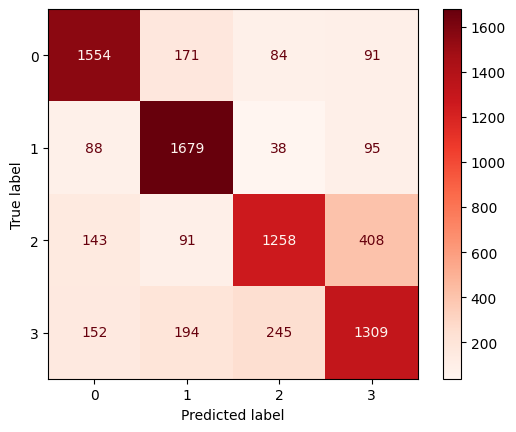

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

logregr = LogisticRegression(random_state=42, max_iter=1000)
logregr.fit(X_train_w2v, y_train_w2v)

y_pred_w2v = logregr.predict(X_test_w2v)
print("Logistic Regression (W2V) Accuracy:", accuracy_score(y_test_w2v, y_pred_w2v))

cr = classification_report(y_test_w2v, y_pred_w2v)
print("\nClassification Report:\n", cr)

cm = confusion_matrix(y_test_w2v, y_pred_w2v)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Reds", values_format="d")

In [67]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

for n in [100]:
    model = XGBClassifier(
        n_estimators=300,
        max_depth=20,
        random_state=42,
        tree_method='hist',  # Use GPU for histogram-based algorithm
        device='cuda'           # Use CUDA device (GPU)
    )
    
    model.fit(X_train_w2v, y_train_w2v)
    
    acc = model.score(X_test_w2v, y_test_w2v)
    print(f"n_estimators={n}, Test Accuracy={acc:.4f}")

n_estimators=100, Test Accuracy=0.7816


Test Accuracy: 0.781578947368421
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1900
           1       0.81      0.87      0.84      1900
           2       0.78      0.73      0.75      1900
           3       0.72      0.70      0.71      1900

    accuracy                           0.78      7600
   macro avg       0.78      0.78      0.78      7600
weighted avg       0.78      0.78      0.78      7600



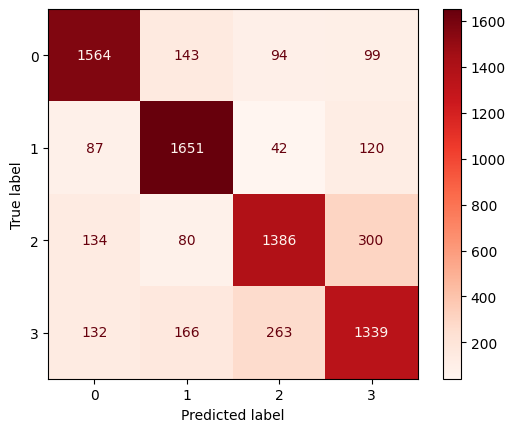

In [68]:
y_pred_w2v = model.predict(X_test_w2v)
print("Test Accuracy:", accuracy_score(y_test_w2v, y_pred_w2v))
print(classification_report(y_test_w2v, y_pred_w2v))

cm = confusion_matrix(y_test_w2v, y_pred_w2v)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Reds", values_format="d")

In [69]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_w2v, y_train_w2v, test_size=0.2, random_state=42, stratify=y_train_w2v
)

In [70]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(100,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(4, activation='softmax') 
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


2025-09-09 09:19:20.507178: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757409560.767122      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757409560.838540      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1757409574.450723      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13884 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1757409574.451395      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability:

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,444 (83.77 KB)

 Trainable params: 21,444 (83.77 KB)

 Non-trainable params: 0 (0.00 B)

In [71]:
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=60000)

Epoch 1/50


I0000 00:00:1757409577.291610     163 service.cc:148] XLA service 0x7815d4306910 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757409577.292508     163 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1757409577.292529     163 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1757409577.519759     163 cuda_dnn.cc:529] Loaded cuDNN version 90300


1/2 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.2387 - loss: 1.4107

I0000 00:00:1757409579.403225     163 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.2409 - loss: 1.4069 - val_accuracy: 0.3670 - val_loss: 1.3791
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.2635 - loss: 1.3867 - val_accuracy: 0.3155 - val_loss: 1.3664
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.2917 - loss: 1.3751 - val_accuracy: 0.3850 - val_loss: 1.3544
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.3268 - loss: 1.3625 - val_accuracy: 0.4728 - val_loss: 1.3442
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.3554 - loss: 1.3519 - val_accuracy: 0.4201 - val_loss: 1.3350
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.3729 - loss: 1.3405 - val_accuracy: 0.4355 - val_loss: 1.3232
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.3906 - loss: 1.3274 - val_accuracy: 0.5242 - val_loss: 1.3075
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.4014 - loss: 1.3157 - val_accuracy: 0.5260 - val_loss: 1.2909
Epoch 9/50
2/

238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Classification report:
              precision    recall  f1-score   support

           0       0.73      0.80      0.76      1900
           1       0.69      0.80      0.75      1900
           2       0.68      0.61      0.64      1900
           3       0.58      0.50      0.54      1900

    accuracy                           0.68      7600
   macro avg       0.67      0.68      0.67      7600
weighted avg       0.67      0.68      0.67      7600



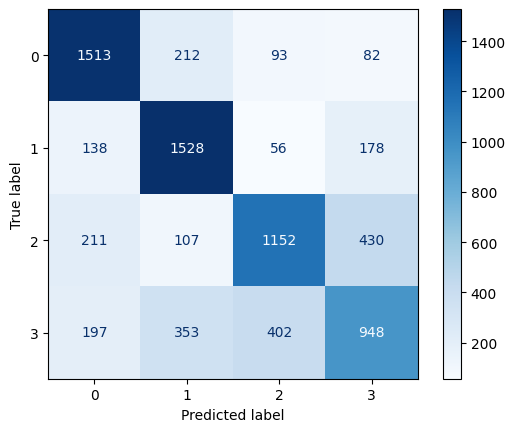

In [74]:
y_pred_probs = model.predict(X_test_w2v)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test_w2v, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")

# Classification report
cr = classification_report(y_test_w2v, y_pred)
print(f"Classification report:\n{cr}")

## comparison

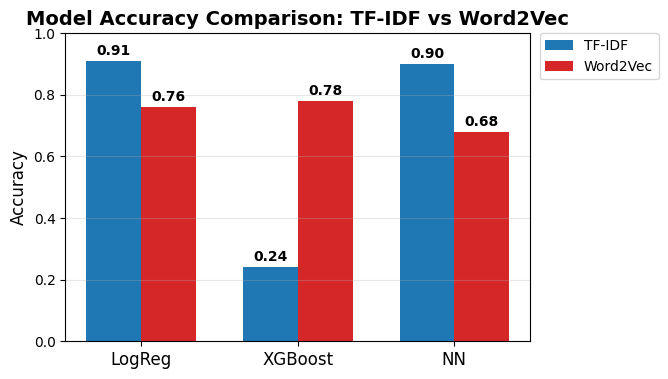

In [75]:
import matplotlib.pyplot as plt
import numpy as np

# Example results (replace with your real results)
results = {
    "LogReg": {"TF-IDF": 0.91, "Word2Vec": 0.76},
    "XGBoost": {"TF-IDF": 0.24, "Word2Vec": 0.78},
    "NN": {"TF-IDF": 0.90, "Word2Vec": 0.68},
}

# Convert into lists for plotting
models = list(results.keys())
tfidf_acc = [results[m]["TF-IDF"] for m in models]
w2v_acc = [results[m]["Word2Vec"] for m in models]

x = np.arange(len(models))  # positions on x-axis
width = 0.35                # bar width

# Plot
plt.figure(figsize=(6,4))
bars1 = plt.bar(x - width/2, tfidf_acc, width, label="TF-IDF", color="#1f77b4")  # vibrant blue
bars2 = plt.bar(x + width/2, w2v_acc, width, label="Word2Vec", color="#d62728")  # vibrant red

plt.xticks(x, models, fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Model Accuracy Comparison: TF-IDF vs Word2Vec", fontsize=14, fontweight="bold")
plt.ylim(0,1)
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0.)
plt.grid(axis="y", alpha=0.3)

# Add value labels on top of bars
for bar in bars1 + bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
             f"{height:.2f}", ha='center', va='bottom', fontsize=10, fontweight="bold")

plt.show()
